In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年03月03日 17时05分05秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

# sc.pp.subsample(fadata, n_obs=100) # 直接采样，细胞数量特别少时，某些聚类采集不到
# 手动保存每类的前两个细胞
obs = fadata.obs.copy()
obs.reset_index(inplace=True)
index = obs.groupby(cluster_key).apply(lambda x: x.head(2))["index"]
fadata = fadata[index]

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(
/tmp/ipykernel_872899/980782529.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index = obs.groupby(cluster_key).apply(lambda x: x.head(2))["index"]
/tmp/ipykernel_872899/980782529.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pa

AnnData object with n_obs × n_vars = 16 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:261: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  milestone_emb = np.array(list(obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))


[2025年03月03日 17时05分06秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (211, 16), finished!                                       


AnnData object with n_obs × n_vars = 16 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

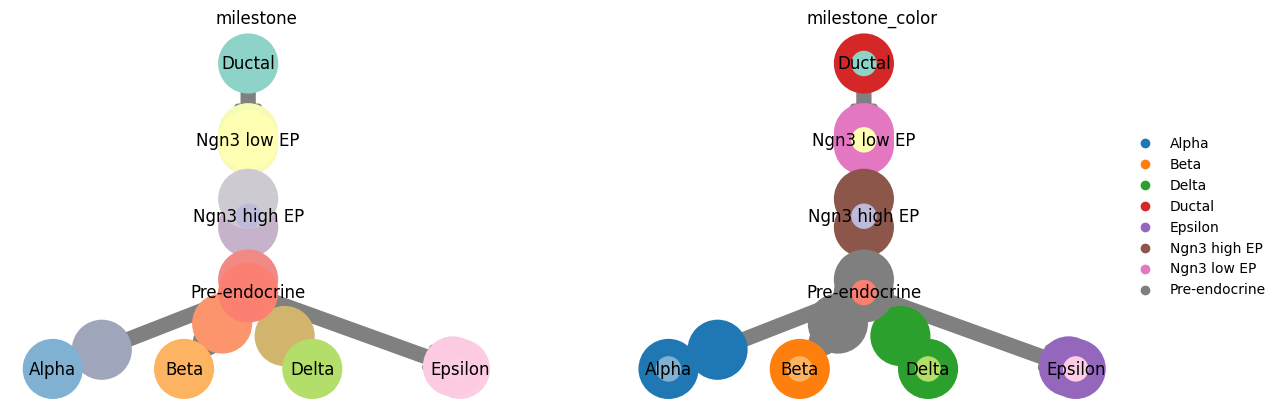

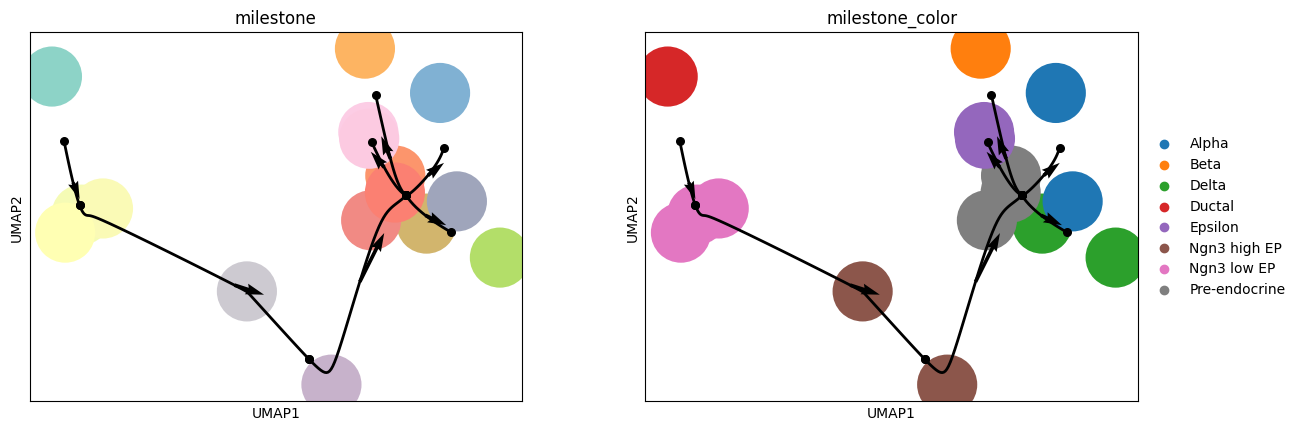

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

                        DEBUG    FunctionBackend __init__                                                          
                        INFO     Loaded function: <function cf_paga at 0x75d59a261f30> from                        
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 paga.py                                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x75d599da0dc0>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


[2025年03月03日 17时05分09秒] DEBUG    FateAnnData add_trajectory_branch                                           
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  branches["length"] = adata.obs[[cluster_key, "dpt_pseudotime"]].groupby(cluster_key).apply(lambda x: x["dpt_pseudotime"].max() - x["dpt_pseudotime"].min() + epsilon).reset_index()[0]
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the 

[2025年03月03日 17时05分10秒] DEBUG    add waypoints shape is (214, 16), finished!                                 
                        DEBUG    FunctionBackend __init__                                                          
                        INFO     Loaded function: <function cf_comp1 at 0x75d57ebb6320> from                       
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 comp1.py                                                                          
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x75d59a2ff6a0>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                              

...

/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

                        DEBUG    add waypoints shape is (210, 16), finished!                                       
                        DEBUG    FunctionBackend __init__                                                          
                        INFO     Loaded function: <function cf_graph_mst at 0x75d57c399360> from                   
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 graph_mst.py                                                                      
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x75d5863d1c90>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    FateAnnData add_trajectory             

/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

                        DEBUG    add waypoints shape is (214, 16), finished!                                       


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

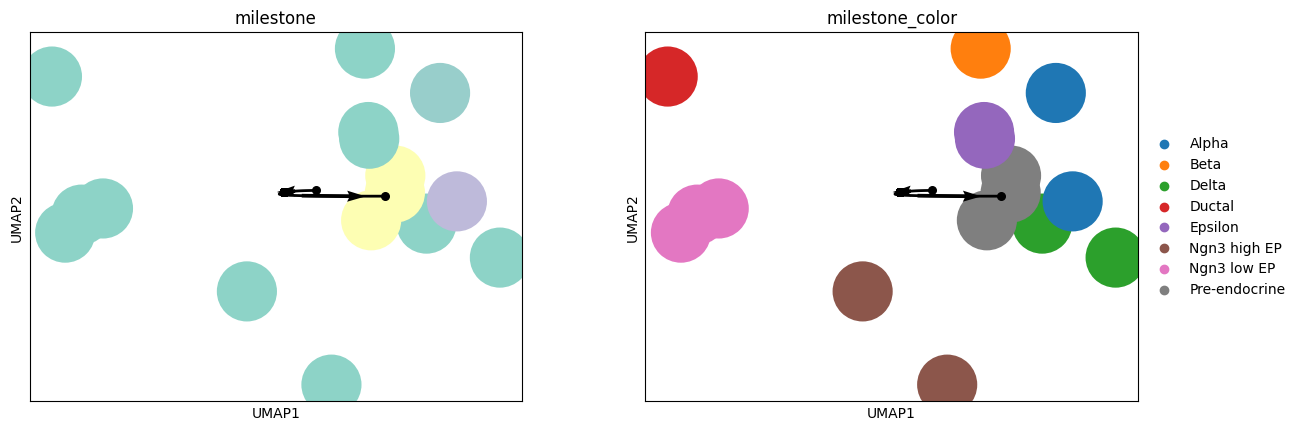

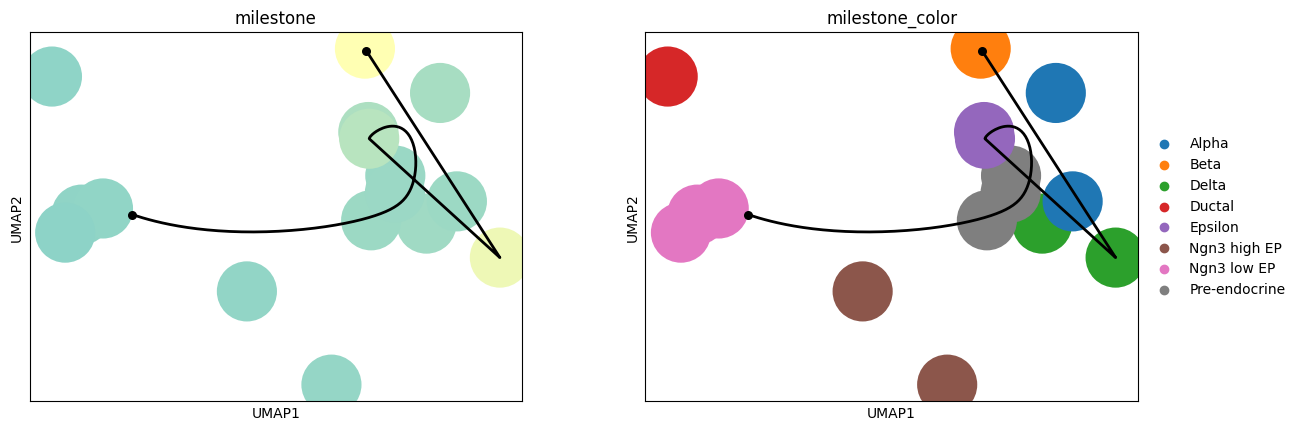

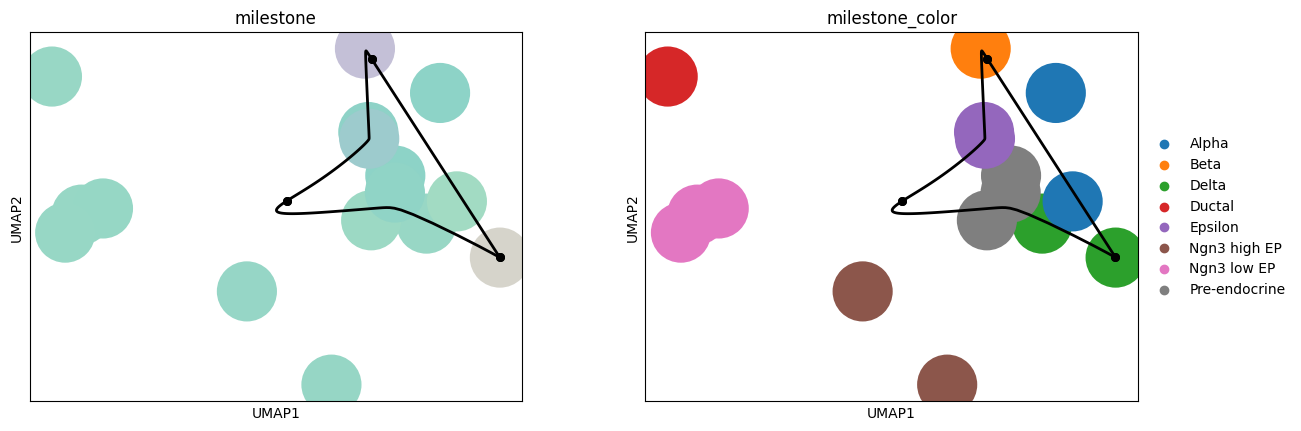

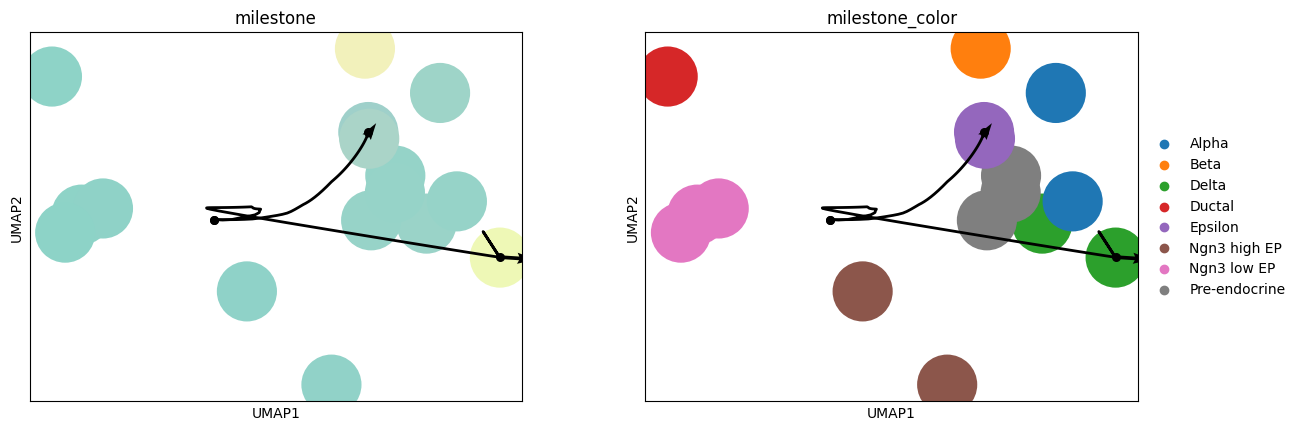

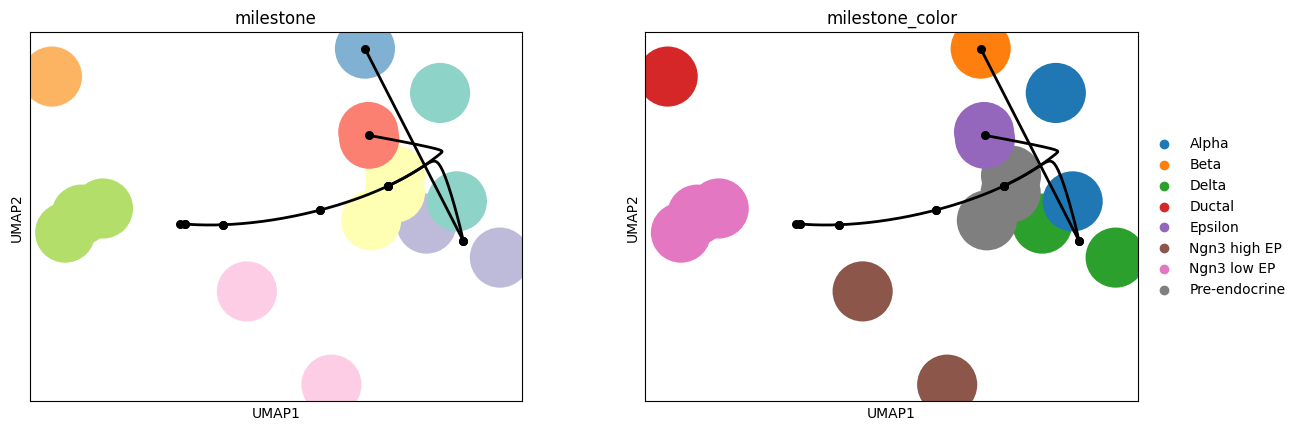

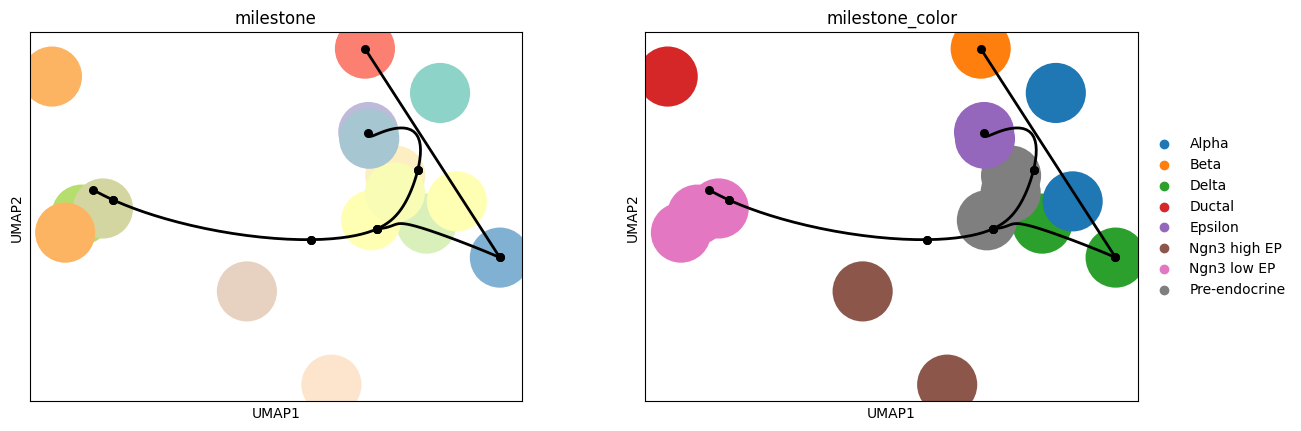

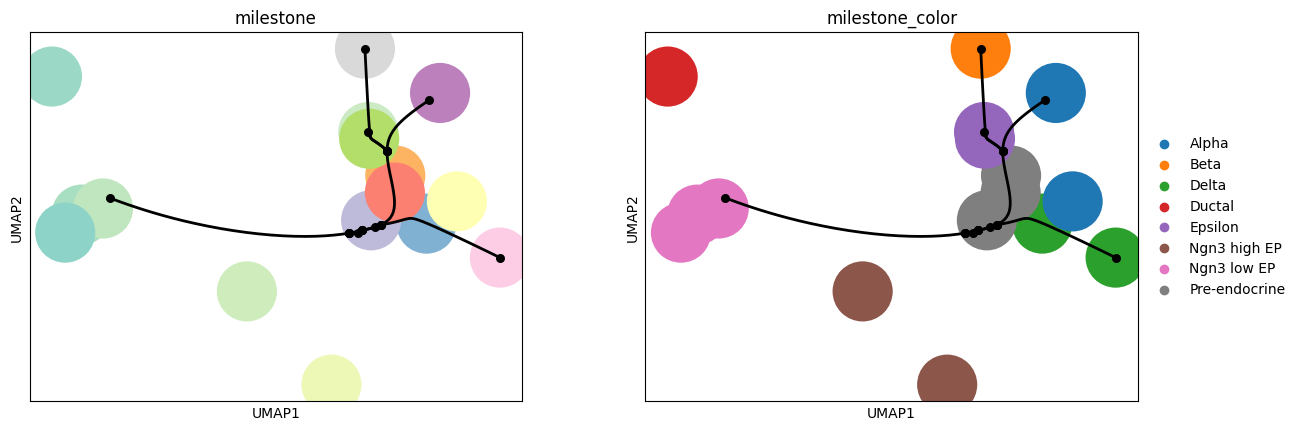

In [5]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)